In [1]:
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
from torch import nn
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from peft import get_peft_model, LoraConfig, TaskType
import pandas as pd
import nltk

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_vibe/PS_train.csv')
df_dev = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_vibe/PS_dev.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_vibe/PS_test_without_labels.csv')

In [6]:
df_train.head()

,content,labels
0,தென்காசி தொகுதி புதிய தமிழகம் கட்சி வேட்பாளர் ...,Neutral
1,அண்ணன் இதனை சூசகமாக 11 மாதங்கள் முன்பே பேட்டிய...,Substantiated
2,ஒரு வருடம் ஆகி விட்டது இந்த துயரம் நேர்ந்து......,Opinionated
3,"எடப்பாடியை கண்டுகொள்ளாத ""எடப்பாடி""🫢\n ---\nஆதர...",Positive
4,எங்களின் அரசியல் அடுத்த தலைமுறைக்குமானது \n#மக...,Opinionated


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4352 entries, 0 to 4351
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  4352 non-null   object
 1   labels   4352 non-null   object
dtypes: object(2)
memory usage: 68.1+ KB


In [8]:
df_train.describe()

,content,labels
count,4352,4352
unique,4181,7
top,🎙️நமது சின்னம் ஒலிவாங்கி🎙️\n\n#மக்களின்_சின்னம...,Opinionated
freq,11,1361


In [9]:
df_train['labels'].value_counts()

,count
labels,
Opinionated,1361
Sarcastic,790
Neutral,637
Positive,575
Substantiated,412
Negative,406
None of the above,171


In [10]:
df_dev['labels'].value_counts()

,count
labels,
Opinionated,153
Sarcastic,115
Neutral,84
Positive,69
Substantiated,52
Negative,51
None of the above,20


In [11]:
df_train['labels'].describe()

,labels
count,4352
unique,7
top,Opinionated
freq,1361


#Data Analysis

Text(0.5, 1.0, 'Frequency of Classes')

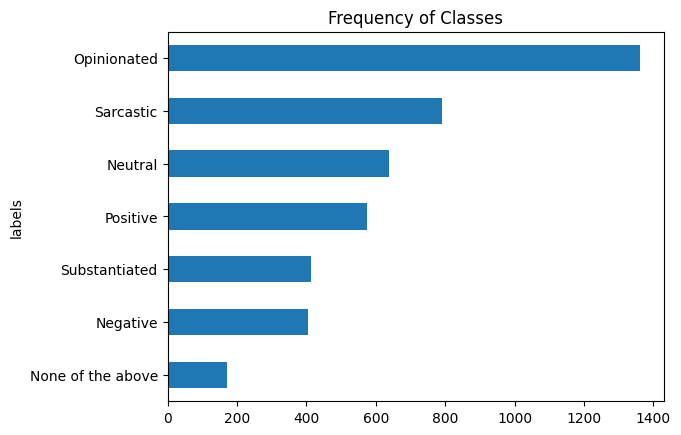

In [12]:
import matplotlib.pyplot as plt
label_counts = df_train['labels'].value_counts(ascending= True)
label_counts.plot.barh()
plt.title('Frequency of Classes')

In [13]:
df_train['Words per content'] = df_train['content'].apply(lambda x : len(nltk.word_tokenize(x)))

<Axes: title={'center': 'Words per content'}, xlabel='labels'>

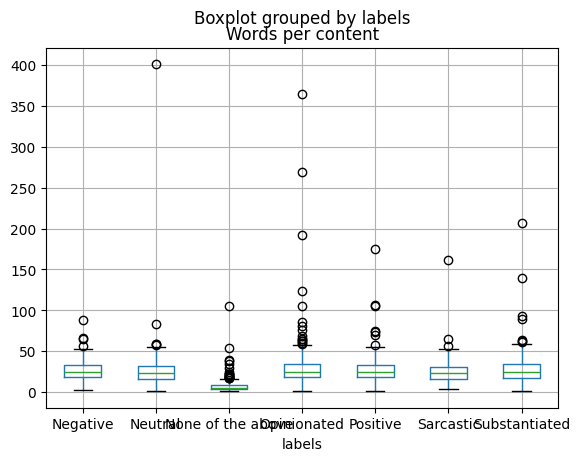

In [14]:
df_train.boxplot("Words per content", by= 'labels')

In [15]:
!pip install emoji indic-nlp-library evaluate

In [16]:
import re
import emoji
from indicnlp.normalize.indic_normalize import IndicNormalizerFactory

factory = IndicNormalizerFactory()
normalizer = factory.get_normalizer("ta")

def preprocess_text_v2(text):
    text = emoji.demojize(text, delimiters=(" :", ": "))
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\u0B80-\u0BFFa-zA-Z0-9\s.,!?:;_"\'()%-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [17]:
df_train['clean_text'] = df_train['content'].apply(preprocess_text_v2)
df_dev['clean_text'] = df_dev['content'].apply(preprocess_text_v2)
df_test['clean_text'] = df_test['content'].apply(preprocess_text_v2)

In [18]:
from imblearn.over_sampling import RandomOverSampler
X_indices = df_train.index.values.reshape(-1, 1)
y_labels = df_train['labels'].values
ros = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = ros.fit_resample(X_indices, y_labels)
balanced_train_df = df_train.iloc[X_resampled.flatten()].reset_index(drop=True)

In [19]:
from transformers import AutoTokenizer
model_ckpt = "xlm-roberta-base"
tokenizer= AutoTokenizer.from_pretrained(model_ckpt)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#Data Loader and Train Test Split

In [20]:
from datasets import Dataset, DatasetDict

In [21]:
dataset = DatasetDict(
    {'train':Dataset.from_pandas(balanced_train_df, preserve_index= False),
    'test':Dataset.from_pandas(df_test, preserve_index= False),
    'validation':Dataset.from_pandas(df_dev, preserve_index= False)}
)
dataset

DatasetDict({
    train: Dataset({
        features: ['content', 'labels', 'Words per content', 'clean_text'],
        num_rows: 9527
    })
    test: Dataset({
        features: ['content', 'clean_text'],
        num_rows: 544
    })
    validation: Dataset({
        features: ['content', 'labels', 'clean_text'],
        num_rows: 544
    })
})

In [22]:
def tokenize(batch):
  temp = tokenizer(batch['content'], padding= True, truncation= True, max_length=128)
  return temp


In [23]:
encoded = dataset.map(tokenize, batched= True, batch_size= None)

Map:   0%|          | 0/9527 [00:00<?, ? examples/s]

Map:   0%|          | 0/544 [00:00<?, ? examples/s]

Map:   0%|          | 0/544 [00:00<?, ? examples/s]

In [24]:
label_list = ['Neutral' ,'Substantiated', 'Opinionated', 'Positive', 'Sarcastic', 'Negative'
, 'None of the above']

In [25]:
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i:label for i,label in enumerate(label_list)}

In [26]:
def map_labels_to_id(batch):
    batch['labels'] = label2id[batch['labels']]
    return batch

In [27]:
encoded['train'] = encoded['train'].map(map_labels_to_id)
encoded['validation'] = encoded['validation'].map(map_labels_to_id)

Map:   0%|          | 0/9527 [00:00<?, ? examples/s]

Map:   0%|          | 0/544 [00:00<?, ? examples/s]

In [28]:
encoded['train'].set_format("torch", columns=["input_ids", "attention_mask", "labels"])
encoded['validation'].set_format("torch", columns=["input_ids", "attention_mask", "labels"])
encoded['test'].set_format("torch", columns=["input_ids", "attention_mask"])

#Model Building

In [29]:
from transformers import AutoModelForSequenceClassification, AutoConfig
import torch

In [30]:
num_labels= len(label2id)
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = AutoConfig.from_pretrained(model_ckpt, label2id= label2id, id2label=id2label)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config= config).to(device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
from transformers import TrainingArguments

In [32]:
import evaluate
import numpy as np

accuracy = evaluate.load('accuracy')
def compute_metrics_evaluate(eval_pred):
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis= 1)
  return accuracy.compute(predictions= predictions, references= labels)

In [33]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)


    macro_f1 = f1_score(labels, predictions, average='macro')
    accuracy = accuracy_score(labels, predictions)
    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1
    }

#Trainer and Testing

In [34]:
from transformers import Trainer

In [35]:
from transformers import set_seed
SEED_VALUE = 42
set_seed(SEED_VALUE)

XLM-R + LoRA + Optuna

In [36]:
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=2e-5,weight_decay=0.01)

In [37]:
 peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["query", "value"]
    )


In [38]:
model_lora_optuna = get_peft_model(model, peft_config)

In [39]:
lr = 0.00013142284004666528
wd = 0.0983991327554873
adam_beta1 = 0.8248433777037623
adam_epsilon = 6.977740005470223e-08
training_args = TrainingArguments(
    seed=SEED_VALUE,
    data_seed=SEED_VALUE,
    output_dir="./final_model_best",
    learning_rate= lr,
    num_train_epochs=10,
    weight_decay= wd,
    per_device_train_batch_size=64,
    per_device_eval_batch_size = 64*2,
    optim="adamw_torch",
    adam_beta1=0.8142790691279208,
    adam_epsilon=6.339871072497331e-08,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=1,
    gradient_accumulation_steps=1,
    fp16=True,
    report_to="none"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.738330,0.189338,0.215257
2,No log,1.726227,0.295956,0.271850
3,No log,1.700790,0.314338,0.332312
4,1.631605,1.711014,0.288603,0.330212
5,1.631605,1.670531,0.301471,0.336662
6,1.631605,1.682784,0.294118,0.348849
7,1.502163,1.662457,0.321691,0.351509
8,1.502163,1.673357,0.305147,0.340876
9,1.502163,1.664100,0.336397,0.361100
10,1.502163,1.663516,0.318015,0.356783


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1490, training_loss=1.5275384070889262, metrics={'train_runtime': 578.2997, 'train_samples_per_second': 164.742, 'train_steps_per_second': 2.577, 'total_flos': 6353690671856640.0, 'train_loss': 1.5275384070889262, 'epoch': 10.0})

In [40]:
def get_clean_model():
    return AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)

XLM-R (Full Fine - Tuning)

In [41]:
training_args_ft = TrainingArguments(
    output_dir="./baseline_full_ft",
    learning_rate=2e-5,
    num_train_epochs=5,
    weight_decay=0.01,
    per_device_train_batch_size=32,
    eval_strategy="epoch",
    metric_for_best_model="macro_f1",
    save_total_limit=1,
    fp16=True
)
model_ft = get_clean_model()
trainer_ft = Trainer(
    model=model_ft, # Model gốc chưa qua LoRA
    args=training_args_ft,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics,
)
trainer_ft.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.707583,0.268382,0.247633
2,1.610386,1.673231,0.308824,0.334696
3,1.610386,1.734099,0.319853,0.353476
4,1.340449,1.796248,0.308824,0.363578
5,1.340449,1.847073,0.318015,0.369610


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1490, training_loss=1.357871814702181, metrics={'train_runtime': 467.2881, 'train_samples_per_second': 101.939, 'train_steps_per_second': 3.189, 'total_flos': 3133464444768000.0, 'train_loss': 1.357871814702181, 'epoch': 5.0})

XLM-R + LoRA

In [42]:
model_raw = get_clean_model()
peft_config = LoraConfig(r=16, lora_alpha=32, target_modules=["query", "value"], task_type=TaskType.SEQ_CLS)
model_lora = get_peft_model(model_raw, peft_config)

training_args_lora = TrainingArguments(
    output_dir="./lora_standard",
    learning_rate=2e-5,
    num_train_epochs=10,
    weight_decay=0.01,
    per_device_train_batch_size=64,
    eval_strategy="epoch",
    metric_for_best_model="macro_f1",
    fp16=True
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics
)
trainer_lora.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.889745,0.226103,0.214931
2,No log,1.753190,0.277574,0.252950
3,No log,1.715791,0.334559,0.304794
4,1.768421,1.734408,0.259191,0.288437
5,1.768421,1.735137,0.246324,0.282589
6,1.768421,1.712128,0.308824,0.320468
7,1.620711,1.709214,0.319853,0.330053
8,1.620711,1.710645,0.321691,0.327512
9,1.620711,1.708558,0.312500,0.323598
10,1.620711,1.703595,0.312500,0.317001


TrainOutput(global_step=1490, training_loss=1.6638188099701132, metrics={'train_runtime': 421.0854, 'train_samples_per_second': 226.249, 'train_steps_per_second': 3.538, 'total_flos': 6353690671856640.0, 'train_loss': 1.6638188099701132, 'epoch': 10.0})

XLM-R + LoRA + Focal Loss

In [43]:
model_raw = get_clean_model()
peft_config = LoraConfig(r=16, lora_alpha=32, target_modules=["query", "value"], task_type=TaskType.SEQ_CLS)
model_lora = get_peft_model(model_raw, peft_config)
class FocalLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(reduction='none')
        ce_loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** 2.0 * ce_loss).mean()
        return (focal_loss, outputs) if return_outputs else focal_loss
trainer_focal = FocalLossTrainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=compute_metrics,
)
trainer_focal.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.329718,0.137868,0.145005
2,No log,1.246796,0.279412,0.229881
3,No log,1.205214,0.301471,0.244132
4,1.276160,1.211068,0.242647,0.273097
5,1.276160,1.212707,0.240809,0.280551
6,1.276160,1.190791,0.294118,0.315486
7,1.139591,1.188941,0.301471,0.320024
8,1.139591,1.188356,0.290441,0.308005
9,1.139591,1.184596,0.295956,0.315062
10,1.139591,1.180096,0.306985,0.318659


TrainOutput(global_step=1490, training_loss=1.1779348488622063, metrics={'train_runtime': 419.96, 'train_samples_per_second': 226.855, 'train_steps_per_second': 3.548, 'total_flos': 6353690671856640.0, 'train_loss': 1.1779348488622063, 'epoch': 10.0})

Analysis

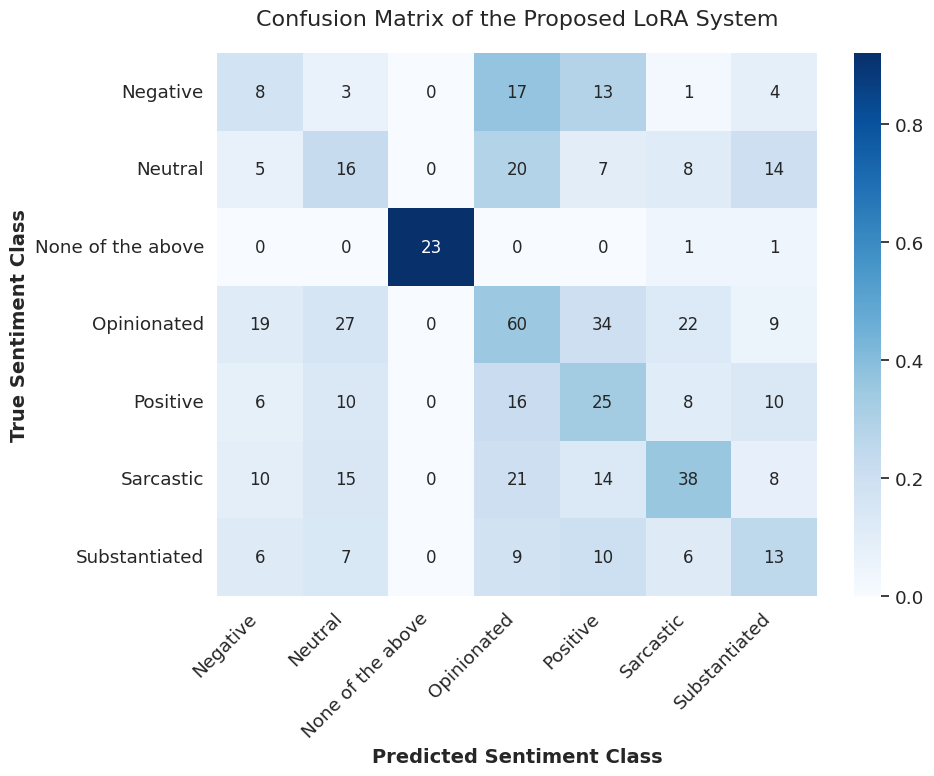

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np


df_true = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_vibe/PS_test.csv")
df_pred = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_vibe/PhucNguyen_political_run3.csv")


y_true = df_true['labels'] # Đảm bảo tên cột khớp với file của bạn
y_pred = df_pred['label']


class_names = ['Negative', 'Neutral', 'None of the above',
               'Opinionated', 'Positive', 'Sarcastic', 'Substantiated']


cm = confusion_matrix(y_true, y_pred, labels=class_names)


cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2) # Tăng kích thước chữ


ax = sns.heatmap(cm_percentage, annot=cm, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names,
                 annot_kws={"size": 12})

plt.title("Confusion Matrix of the Proposed LoRA System", fontsize=16, pad=20)
plt.ylabel("True Sentiment Class", fontsize=14, weight='bold')
plt.xlabel("Predicted Sentiment Class", fontsize=14, weight='bold')


plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()



=== Predicting with trainer ===


Accuracy: 0.3217
Macro F1: 0.3448
Cảnh báo: Không tìm thấy cột 'pid', 'id' hoặc 'ID'. Sử dụng index làm pid.


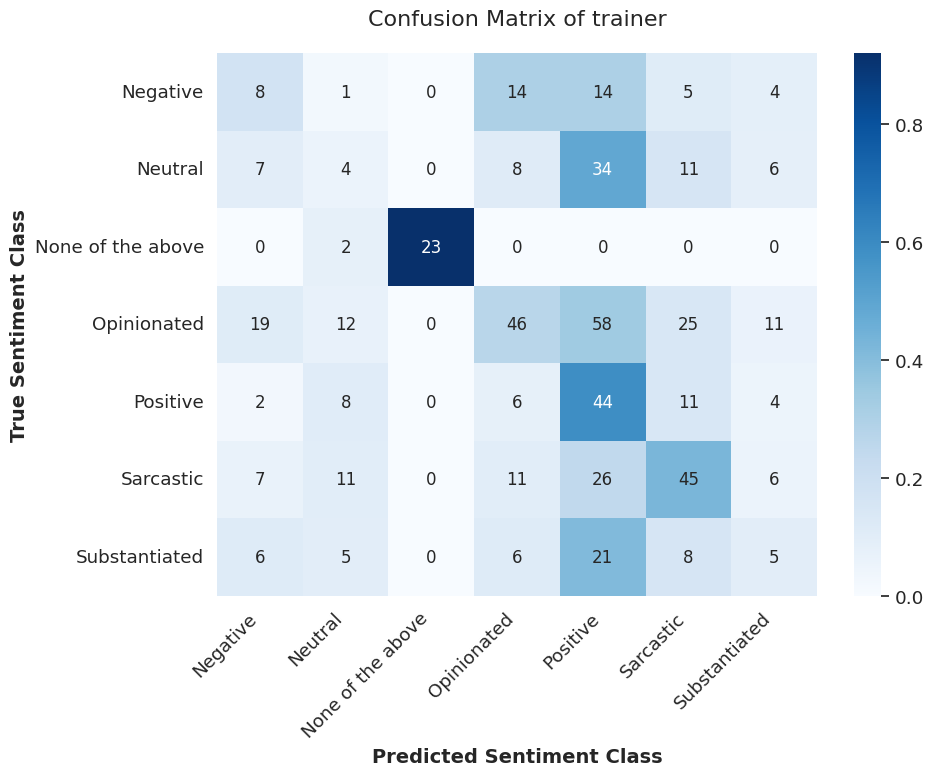


=== Predicting with trainer_ft ===


Accuracy: 0.2923
Macro F1: 0.3415
Cảnh báo: Không tìm thấy cột 'pid', 'id' hoặc 'ID'. Sử dụng index làm pid.


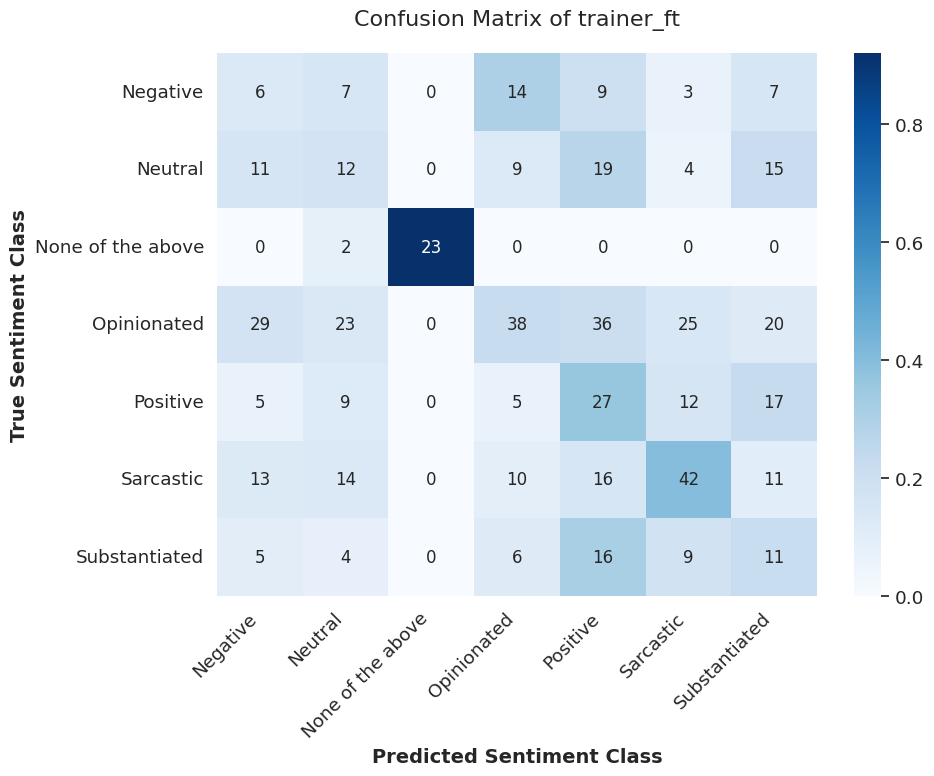


=== Predicting with trainer_lora ===


Accuracy: 0.2978
Macro F1: 0.3003
Cảnh báo: Không tìm thấy cột 'pid', 'id' hoặc 'ID'. Sử dụng index làm pid.


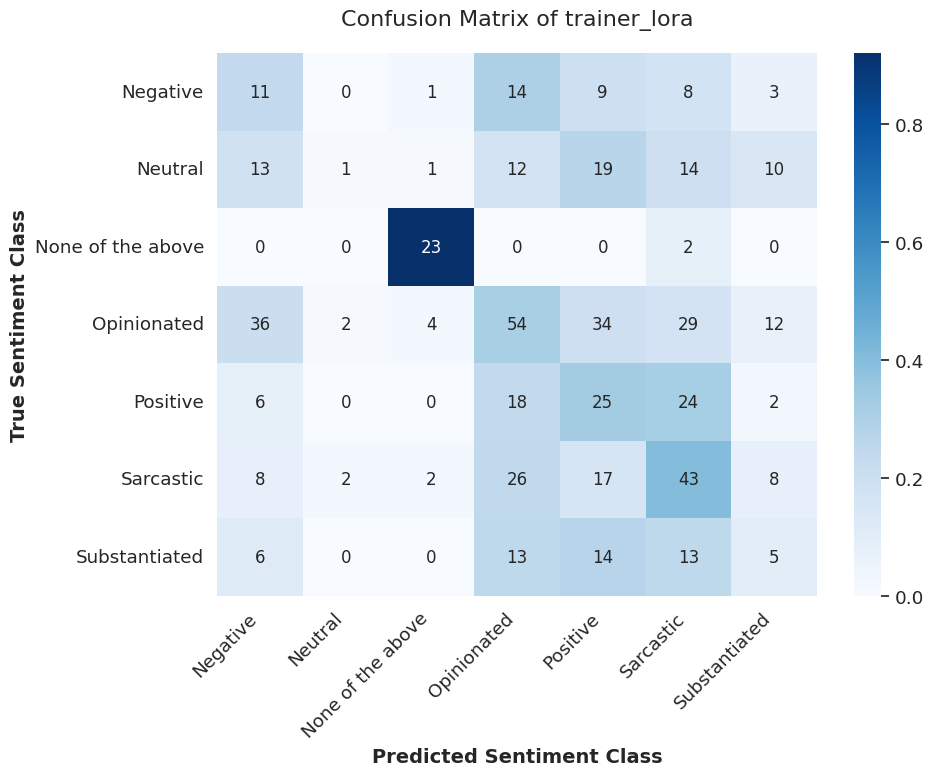


=== Predicting with trainer_focal ===


Accuracy: 0.3438
Macro F1: 0.3301
Cảnh báo: Không tìm thấy cột 'pid', 'id' hoặc 'ID'. Sử dụng index làm pid.


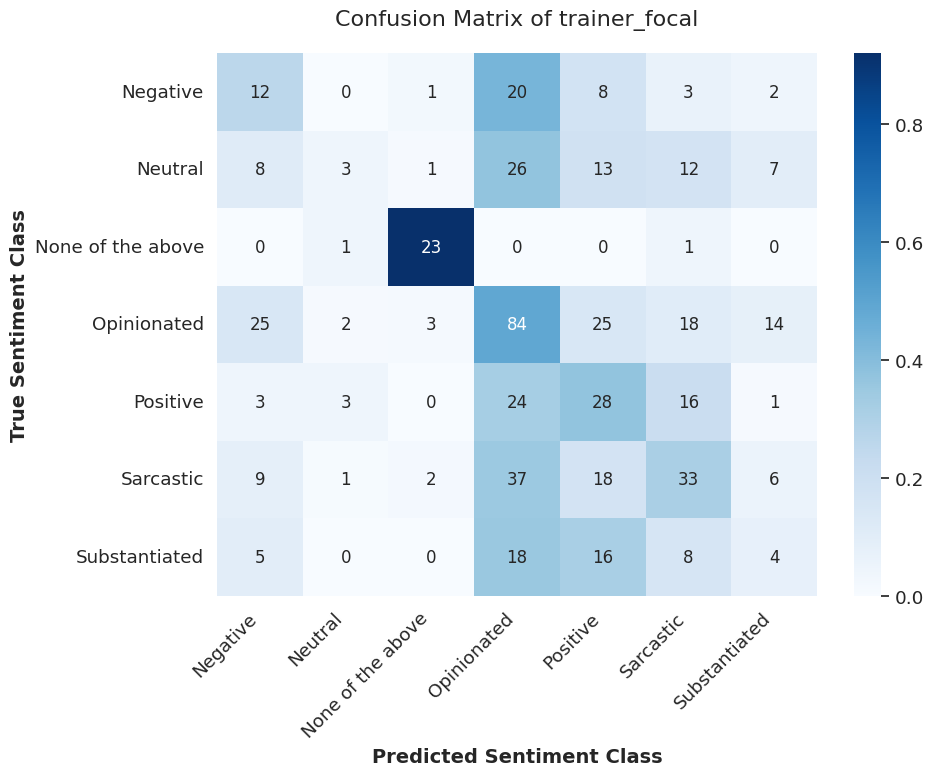


=== Metrics for PhucNguyen_political_run3 ===
Accuracy: 0.3364
Macro F1: 0.3763


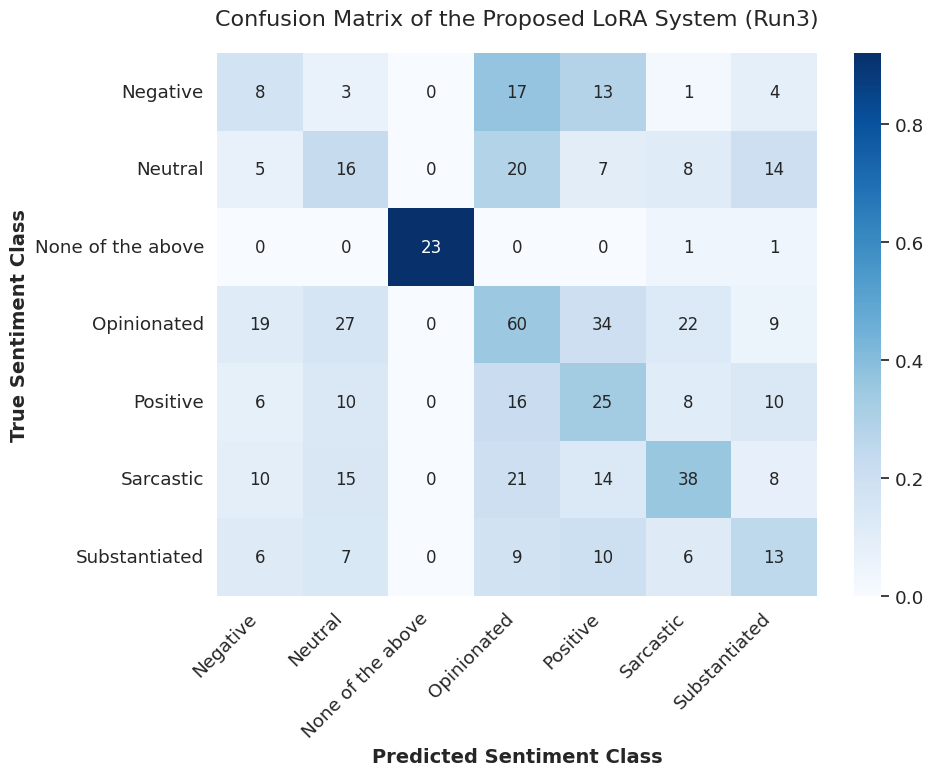

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import numpy as np
from datasets import Dataset
df_true = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_vibe/PS_test.csv")
y_true = df_true['labels']
label2id = {v: k for k, v in id2label.items()}
y_true_numeric = [label2id[label] for label in y_true]
class_names = ['Negative', 'Neutral', 'None of the above',
               'Opinionated', 'Positive', 'Sarcastic', 'Substantiated']
trainers = {
    "trainer": trainer,
     "trainer_ft": trainer_ft,
    "trainer_lora": trainer_lora,
    "trainer_focal": trainer_focal
}
for name, tr in trainers.items():
    print(f"\n=== Predicting with {name} ===")
    predictions_output = tr.predict(encoded['test'])
    preds_indices = np.argmax(predictions_output.predictions, axis=1)
    final_labels = [id2label[idx] for idx in preds_indices]
    acc = accuracy_score(y_true_numeric, preds_indices)
    macro_f1 = f1_score(y_true_numeric, preds_indices, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    submission_df = pd.DataFrame()
    if 'pid' in df_true.columns:
        submission_df['pid'] = df_true['pid']
    elif 'id' in df_true.columns:
        submission_df['pid'] = df_true['id']
    elif 'ID' in df_true.columns:
        submission_df['pid'] = df_true['ID']
    else:
        submission_df['pid'] = df_true.index
        print("Cảnh báo: Không tìm thấy cột 'pid', 'id' hoặc 'ID'. Sử dụng index làm pid.")
    submission_df['label'] = final_labels
    y_pred = final_labels
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    sns.set(font_scale=1.2)
    ax = sns.heatmap(cm_percentage, annot=cm, fmt='d', cmap='Blues',
                      xticklabels=class_names, yticklabels=class_names,
                      annot_kws={"size": 12})
    plt.title(f"Confusion Matrix of {name}", fontsize=16, pad=20)
    plt.ylabel("True Sentiment Class", fontsize=14, weight='bold')
    plt.xlabel("Predicted Sentiment Class", fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{name}_confusion_matrix.png")
    plt.show()
print("\n=== Metrics for PhucNguyen_political_run3 ===")
df_pred = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_vibe/PhucNguyen_political_run3.csv")
y_pred_run3 = df_pred['label']
preds_indices_run3 = [label2id[label] for label in y_pred_run3]
acc_run3 = accuracy_score(y_true_numeric, preds_indices_run3)
macro_f1_run3 = f1_score(y_true_numeric, preds_indices_run3, average='macro')
print(f"Accuracy: {acc_run3:.4f}")
print(f"Macro F1: {macro_f1_run3:.4f}")
cm_run3 = confusion_matrix(y_true, y_pred_run3, labels=class_names)
cm_percentage_run3 = cm_run3.astype('float') / cm_run3.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm_percentage_run3, annot=cm_run3, fmt='d', cmap='Blues',
                  xticklabels=class_names, yticklabels=class_names,
                  annot_kws={"size": 12})
plt.title("Confusion Matrix of the Proposed LoRA System (Run3)", fontsize=16, pad=20)
plt.ylabel("True Sentiment Class", fontsize=14, weight='bold')
plt.xlabel("Predicted Sentiment Class", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("run3_confusion_matrix.png")
plt.show()